# Predictive Mining 1 - how solid are the behavioural groups?

Week five split the 143 profiled owners into three behavioural groups by the way they
use email: a broadcaster/exec group of 8, an outward-facing group of 50, and an internal
majority of 85. The silhouette that picked three groups peaked at about 0.18, which is low,
so the groups are roles on a gradient rather than clean islands. Before the prediction work
leans on them it is worth pushing on two soft spots.

The first is the broadcaster group. It is the smallest, it carries most of the story, and
it is named partly after the executives, so the blunt question is whether we can actually
say who belongs in it. The second is the cluster-profile heatmap from week five. It coloured
nearly every feature at roughly the same intensity, which would say every feature defines the
groups about equally. That looked too tidy, so the second question is which features really do
the separating and which sit at the average and tell us nothing.

This notebook rebuilds the exact week-five clustering, then stress-tests it from both angles.
It reads the cleaned tables under `eda-5/clean/`, the same input the clustering used.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster

import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-5" / "clean" / "messages_clean.parquet").exists():
            return base
    raise FileNotFoundError("eda-5/clean not found above " + str(here))

ROOT = find_root()
CLEAN = ROOT / "eda-5" / "clean"
PLOTS = ROOT / "pred-1" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE = "#6a3d9a"
pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True)))
pio.templates.default = "enron"

def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3)
    _PILImage.open(out).save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out)))
    return fig

def disp(handle):
    sn, _, ini = handle.partition("-")
    return f"{sn.replace('.', ' ').title()} {ini.upper()}".strip()

In [2]:
# Rebuild the week-five behavioural features and the Ward clustering, unchanged.
msg = pd.read_parquet(CLEAN / "messages_clean.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet")

MIN_AUTHORED = 30
authored = msg[msg["sender_person"].notna()].copy()
ac = authored.groupby("sender_person").size()
keep = sorted(ac[ac >= MIN_AUTHORED].index)

a = authored[authored["date_plausible"] & authored["date"].notna()].copy()
a["wknd"] = a["date"].dt.dayofweek >= 5
g = authored.groupby("sender_person"); ag = a.groupby("sender_person")

F = pd.DataFrame(index=keep)
F["n_sent"]        = g.size()
F["med_len"]       = g["body_chars"].median()
F["mean_recip"]    = g["recipient_count"].mean()
F["ext_ratio"]     = g["has_external_recipient"].mean()
F["cc_ratio"]      = g["cc_count"].sum() / g["recipient_count"].sum().replace(0, np.nan)
F["broadcast"]     = authored.assign(b=authored["recipient_count"] > 5).groupby("sender_person")["b"].mean()
F["root_ratio"]    = g["is_thread_root"].mean()
F["wknd_ratio"]    = ag["wknd"].mean()
F["active_months"] = (ag["date"].max() - ag["date"].min()).dt.days / 30.44
F["del_rate"]      = msg.assign(d=msg["folder_group"].eq("deleted")).groupby("mailbox_owner")["d"].mean().reindex(keep)
ei = rcp.merge(msg[["message_id", "sender_person"]], on="message_id")
ei = ei[(ei["channel"] == "to") & ei["is_internal_recipient"] & ~ei["recipient_is_list"]
        & ~ei["is_self"] & ei["sender_person"].notna() & ei["recipient_person"].notna()
        & (ei["sender_person"] != ei["recipient_person"])]
F["out_deg"] = ei.groupby("sender_person")["recipient_person"].nunique().reindex(keep)
F["in_deg"]  = ei.groupby("recipient_person")["sender_person"].nunique().reindex(keep)
F = F.reindex(keep).fillna(F.median())

Fraw = F.copy()
LOGCOLS = ["n_sent", "med_len", "mean_recip", "active_months", "out_deg", "in_deg"]
for c in LOGCOLS:
    F[c] = np.log1p(F[c])
FEATS = list(F.columns)
PRETTY = {"n_sent": "messages sent", "med_len": "median body length",
    "mean_recip": "recipients per message", "ext_ratio": "share external",
    "cc_ratio": "Cc share", "broadcast": "share to >5 people",
    "root_ratio": "thread-opening share", "wknd_ratio": "weekend share",
    "active_months": "active months", "del_rate": "mailbox deletion rate",
    "out_deg": "people written to", "in_deg": "people writing in"}

X = StandardScaler().fit_transform(F.values)
Z = linkage(X, method="ward")
clabel = fcluster(Z, 3, criterion="maxclust")
Fraw["cluster"] = clabel
prof = Fraw.groupby("cluster")[FEATS].mean()

# name the clusters by their defining feature, same rule as week five
ex  = prof["broadcast"].idxmax(); used = {ex}
out = prof.loc[~prof.index.isin(used), "ext_ratio"].idxmax(); used.add(out)
maj = [c for c in prof.index if c not in used][0]
names = {ex: "Broadcasters / execs", out: "Outward-facing", maj: "Internal majority"}
cl_name = {h: names[clabel[i]] for i, h in enumerate(keep)}
bcast = [h for h in keep if cl_name[h] == "Broadcasters / execs"]
print({names[c]: int((clabel == c).sum()) for c in sorted(prof.index)})
print("broadcaster group:", ", ".join(disp(h) for h in bcast))

{'Outward-facing': 50, 'Broadcasters / execs': 8, 'Internal majority': 85}
broadcaster group: Bailey S, Baughman D, Hain M, Lay K, Panus S, Skilling J, Whalley L, Williams W3


## Can we tell for sure who is in the broadcaster group?

Eight people fall in the broadcaster group. To see how solid that is we look at the membership
three ways.

The first is the silhouette of each member, which compares how close a person sits to their own
group against the nearest other group. A value near one means the person is deep inside the
broadcaster group; a value near zero means they sit on the fence with the internal majority. The
second is a resampling check: we redraw a random 80% of the 143 people six hundred times, rerun the
whole pipeline from scaling to the three-group cut on each draw, and record how often each person
lands back in the broadcaster cluster. A member who returns every time is a fixed part of the group;
one who returns three times in four has a vote that depends on who else is in the sample. The third
is a method swap, checking whether the same eight stay together under k-means and under deeper Ward
cuts into four and five groups.

all 8 stay together under: ['k-means k3', 'Ward k4', 'Ward k5'] (of ['k-means k3', 'Ward k4', 'Ward k5'] )


/tmp/ipykernel_3838618/103731382.py:42: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


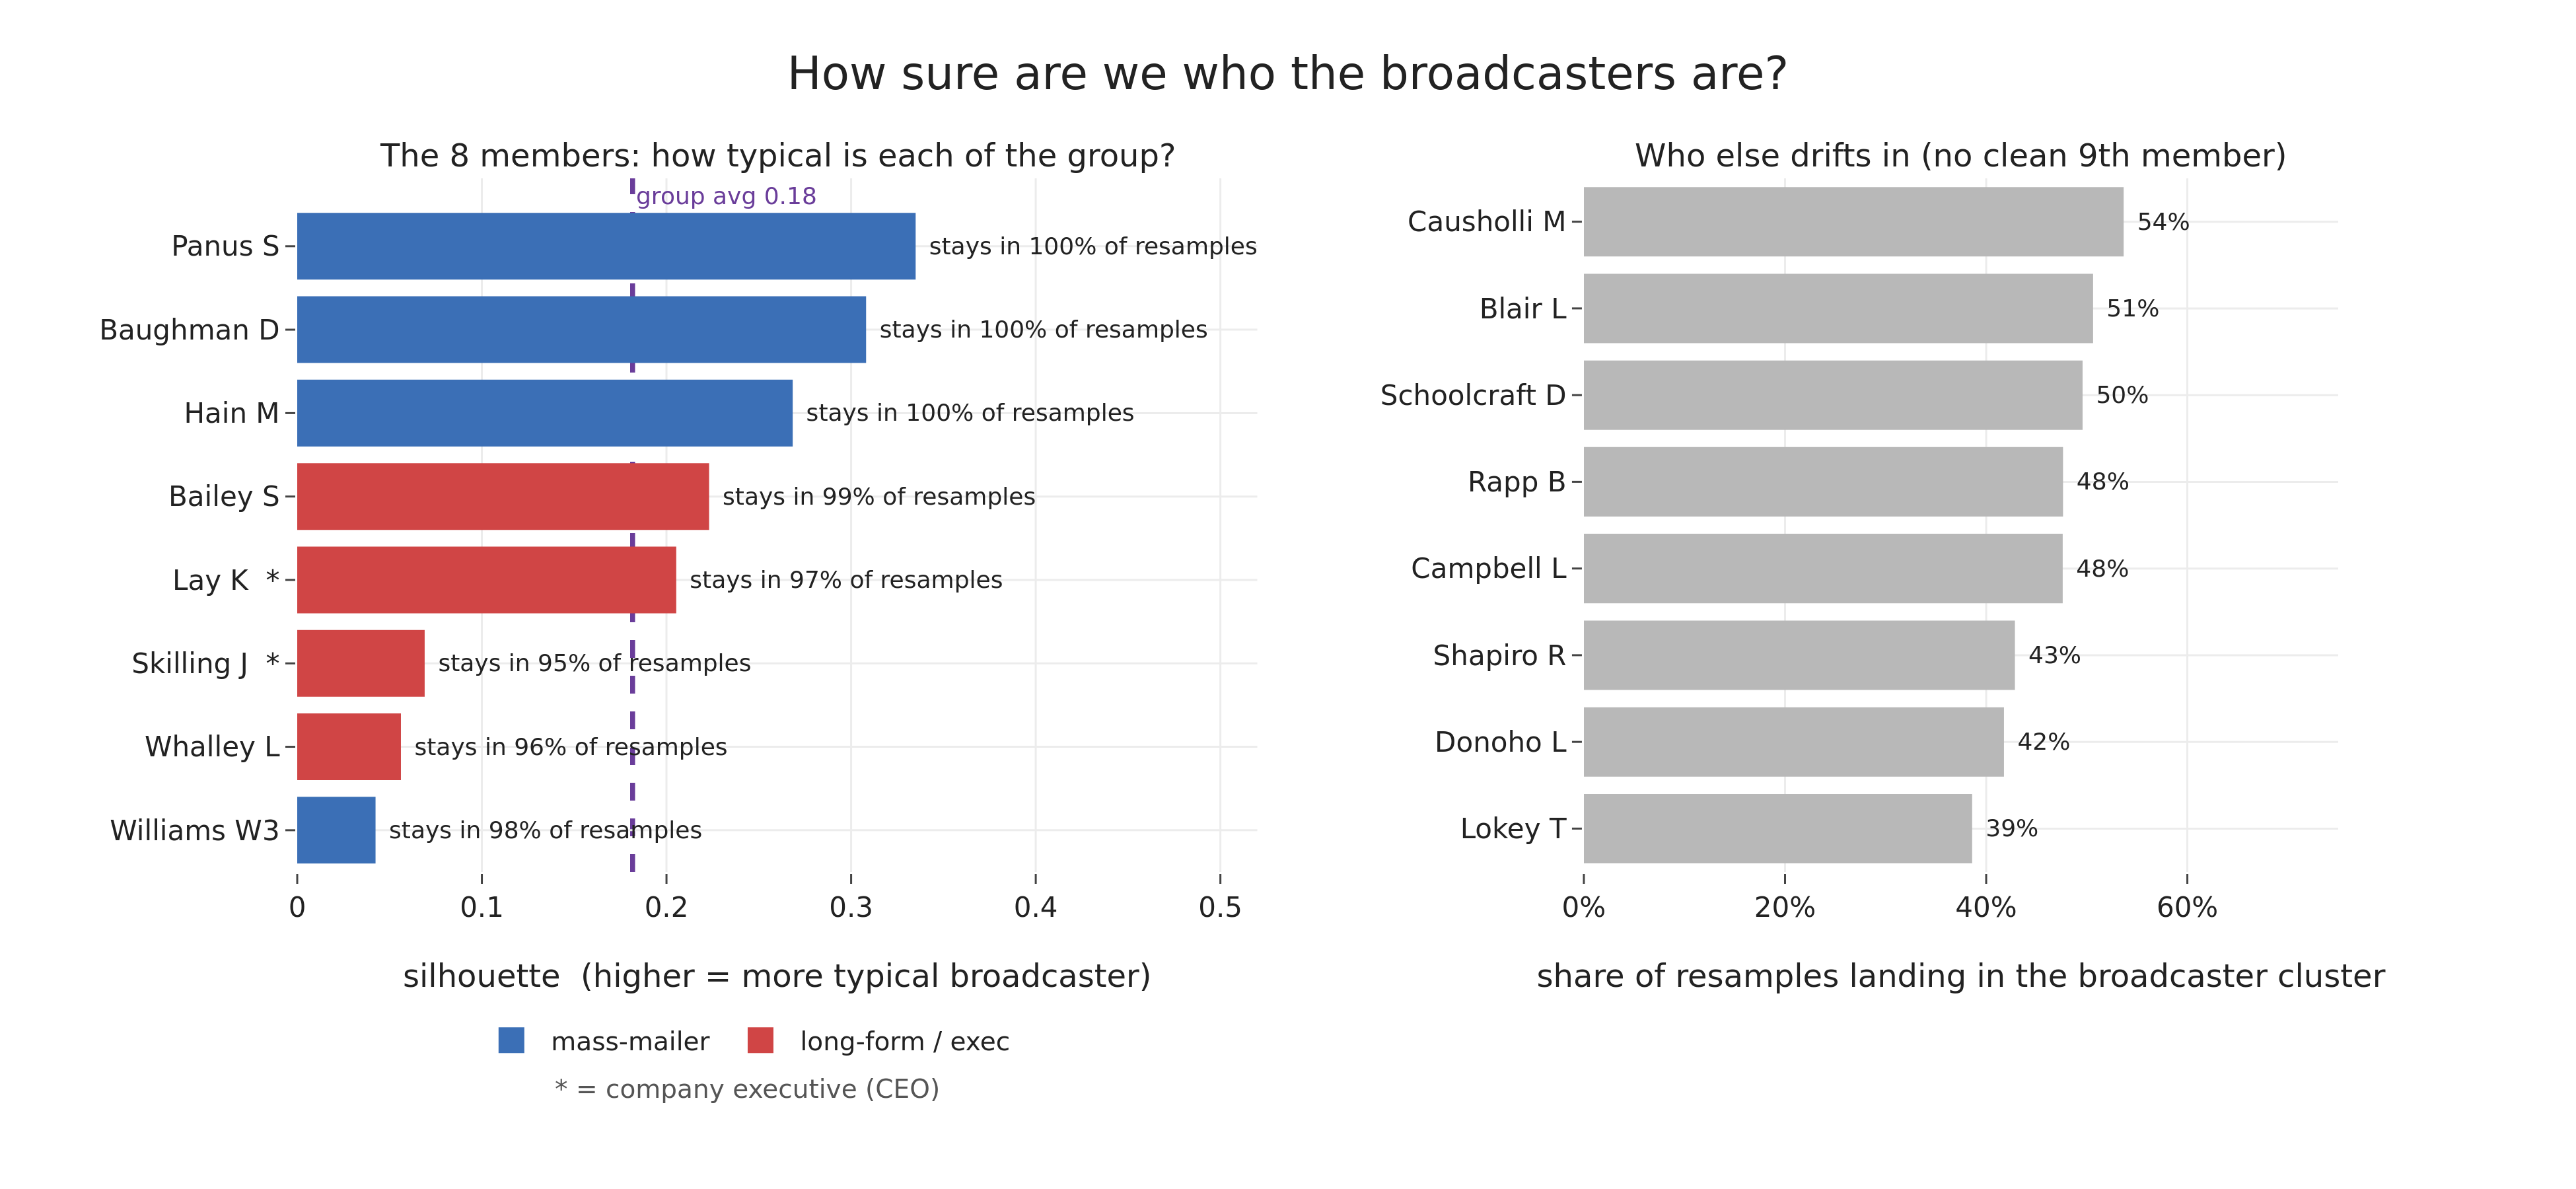

In [3]:
roles = pd.read_parquet(CLEAN / "people_roles.parquet").set_index("owner")
sil = pd.Series(silhouette_samples(X, clabel), index=keep)

rng = np.random.default_rng(0)
rawb = Fraw["broadcast"].values
n = len(keep); m = int(0.8 * n)

def broadcaster_cluster(labels, idx):
    """the resampled cluster with the highest mean raw broadcast rate, matching the week-5 naming"""
    sub_b = rawb[idx]
    return max(np.unique(labels), key=lambda c: sub_b[labels == c].mean())

present = np.zeros(n); inbc = np.zeros(n)
for _ in range(600):
    s = rng.choice(n, m, replace=False)
    Xs = StandardScaler().fit_transform(F.iloc[s].values)
    labs = fcluster(linkage(Xs, "ward"), 3, "maxclust")
    bc = broadcaster_cluster(labs, s)
    present[s] += 1
    inbc[s[labs == bc]] += 1
rate = pd.Series(inbc / np.maximum(present, 1), index=keep)

def bcast_set(labels):
    return set(np.array(keep)[labels == broadcaster_cluster(labels, np.arange(n))])
methods = {"k-means k3": bcast_set(KMeans(3, n_init=10, random_state=0).fit_predict(X) + 1),
           "Ward k4": bcast_set(fcluster(Z, 4, "maxclust")),
           "Ward k5": bcast_set(fcluster(Z, 5, "maxclust"))}
print("all 8 stay together under:",
      [k for k, v in methods.items() if set(bcast) <= v], "(of", list(methods) , ")")

# --- figure ---
ms = sorted(bcast, key=lambda h: sil[h])
execs = {h for h in bcast if h in roles.index and bool(roles.loc[h, "is_executive"])}
flav  = {h: ("mass-mailer" if Fraw.loc[h, "broadcast"] >= 0.30 else "long-form / exec") for h in bcast}
labels = [disp(h) + ("  *" if h in execs else "") for h in ms]
cols   = [BLUE if flav[h] == "mass-mailer" else RED for h in ms]
fringe = rate[[h for h in keep if h not in bcast]].sort_values(ascending=False).head(8).sort_values()

fig = make_subplots(rows=1, cols=2, column_widths=[0.56, 0.44], horizontal_spacing=0.16,
    subplot_titles=["The 8 members: how typical is each of the group?",
                    "Who else drifts in (no clean 9th member)"])
fig.add_trace(go.Bar(y=labels, x=[sil[h] for h in ms], orientation="h", marker_color=cols,
    text=[f" stays in {rate[h]:.0%} of resamples" for h in ms], textposition="outside",
    textfont=dict(size=12), cliponaxis=False, showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
    marker=dict(size=13, color=BLUE, symbol="square"), name="mass-mailer", showlegend=True), row=1, col=1)
fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
    marker=dict(size=13, color=RED, symbol="square"), name="long-form / exec", showlegend=True), row=1, col=1)
fig.add_vline(x=float(sil.mean()), line=dict(color=PURPLE, dash="dash", width=2.5), layer="below", row=1, col=1)
fig.add_annotation(x=float(sil.mean()), y=7.6, text=f"group avg {sil.mean():.2f}", showarrow=False,
    font=dict(size=12, color=PURPLE), xanchor="left", row=1, col=1)
fig.update_xaxes(title_text="silhouette  (higher = more typical broadcaster)", range=[0, 0.52], row=1, col=1)
fig.add_trace(go.Bar(y=[disp(h) for h in fringe.index], x=fringe.values, orientation="h",
    marker_color=GREY, text=[f" {v:.0%}" for v in fringe.values], textposition="outside",
    textfont=dict(size=12), cliponaxis=False, showlegend=False), row=1, col=2)
fig.update_xaxes(title_text="share of resamples landing in the broadcaster cluster",
    range=[0, 0.75], tickformat=".0%", row=1, col=2)
fig.add_annotation(xref="paper", yref="paper", x=0.22, y=-0.34, showarrow=False, xanchor="center",
    text="* = company executive (CEO)", font=dict(size=13, color="#555"))
fig.update_layout(title="How sure are we who the broadcasters are?",
    legend=dict(orientation="h", x=0.22, xanchor="center", y=-0.20, yanchor="top", font=dict(size=13)))
save_fig(fig, "pc1_broadcaster_certainty.png", w=1300, h=600, margin=dict(l=150, r=120, t=90, b=160))

The eight members are a fixed core. Every one of them returns to the broadcaster cluster in at
least 95% of the resamples, and the same eight stay together under k-means and when Ward is pushed to
four and five groups instead of three. When Ward does make those extra cuts it splits the larger groups
and leaves the broadcasters whole, so the eight are a tight knot rather than a loose offcut. On that
measure, yes, we can name the broadcasters.

Two things complicate the picture. The group is held together by sending long mail to many people, but
it does that in two flavours. Baughman, Hain, Panus and Williams are mass-mailers, with a third or more
of their messages going to more than five people at once. Lay, Skilling, Whalley and Bailey reach wide
through long, often external messages rather than raw broadcast volume, and they sit at the low end of
the silhouette, close to the internal-majority boundary. The two actual executives, the only CEOs in
the group, are among its least typical members. Skilling in particular is held in by message length and
external reach, not by broadcasting.

The boundary is also soft. The right panel shows the eight non-members most often pulled into the
broadcaster cluster across the resamples, and they come in around half the time. There is no clean ninth
member waiting to join, only a rotating fringe of people such as Shapiro, Campbell and Causholli who are
in on one draw and out on the next. So the honest answer is layered. The eight-person core is a sure
thing, but the group is not the executive suite, and where it ends is genuinely negotiable.

## Which features actually separate the groups?

The week-five profile heatmap standardised each feature across the three group means, then coloured the
result. With only three numbers per feature, that step forces every feature to come out near one standard
deviation whether or not it carries any signal, so the heatmap made all twelve look about equally
important. A cleaner measure of how much a feature defines the split is eta-squared: of all the spread in
a feature across the 143 people, the share that the three-group split accounts for. A feature near one is
almost entirely explained by which group a person is in; a feature near zero looks the same in every group
and the split tells us nothing about it.

                        heatmap z (broadc.)  population z (broadc.)  eta_squared
weekend share                        -1.149                  -0.199        0.002
thread-opening share                  1.036                   0.493        0.031
mailbox deletion rate                 0.805                   0.503        0.082
share to >5 people                    1.145                   2.550        0.426
recipients per message                1.152                   3.341        0.622


/tmp/ipykernel_3838618/103731382.py:42: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


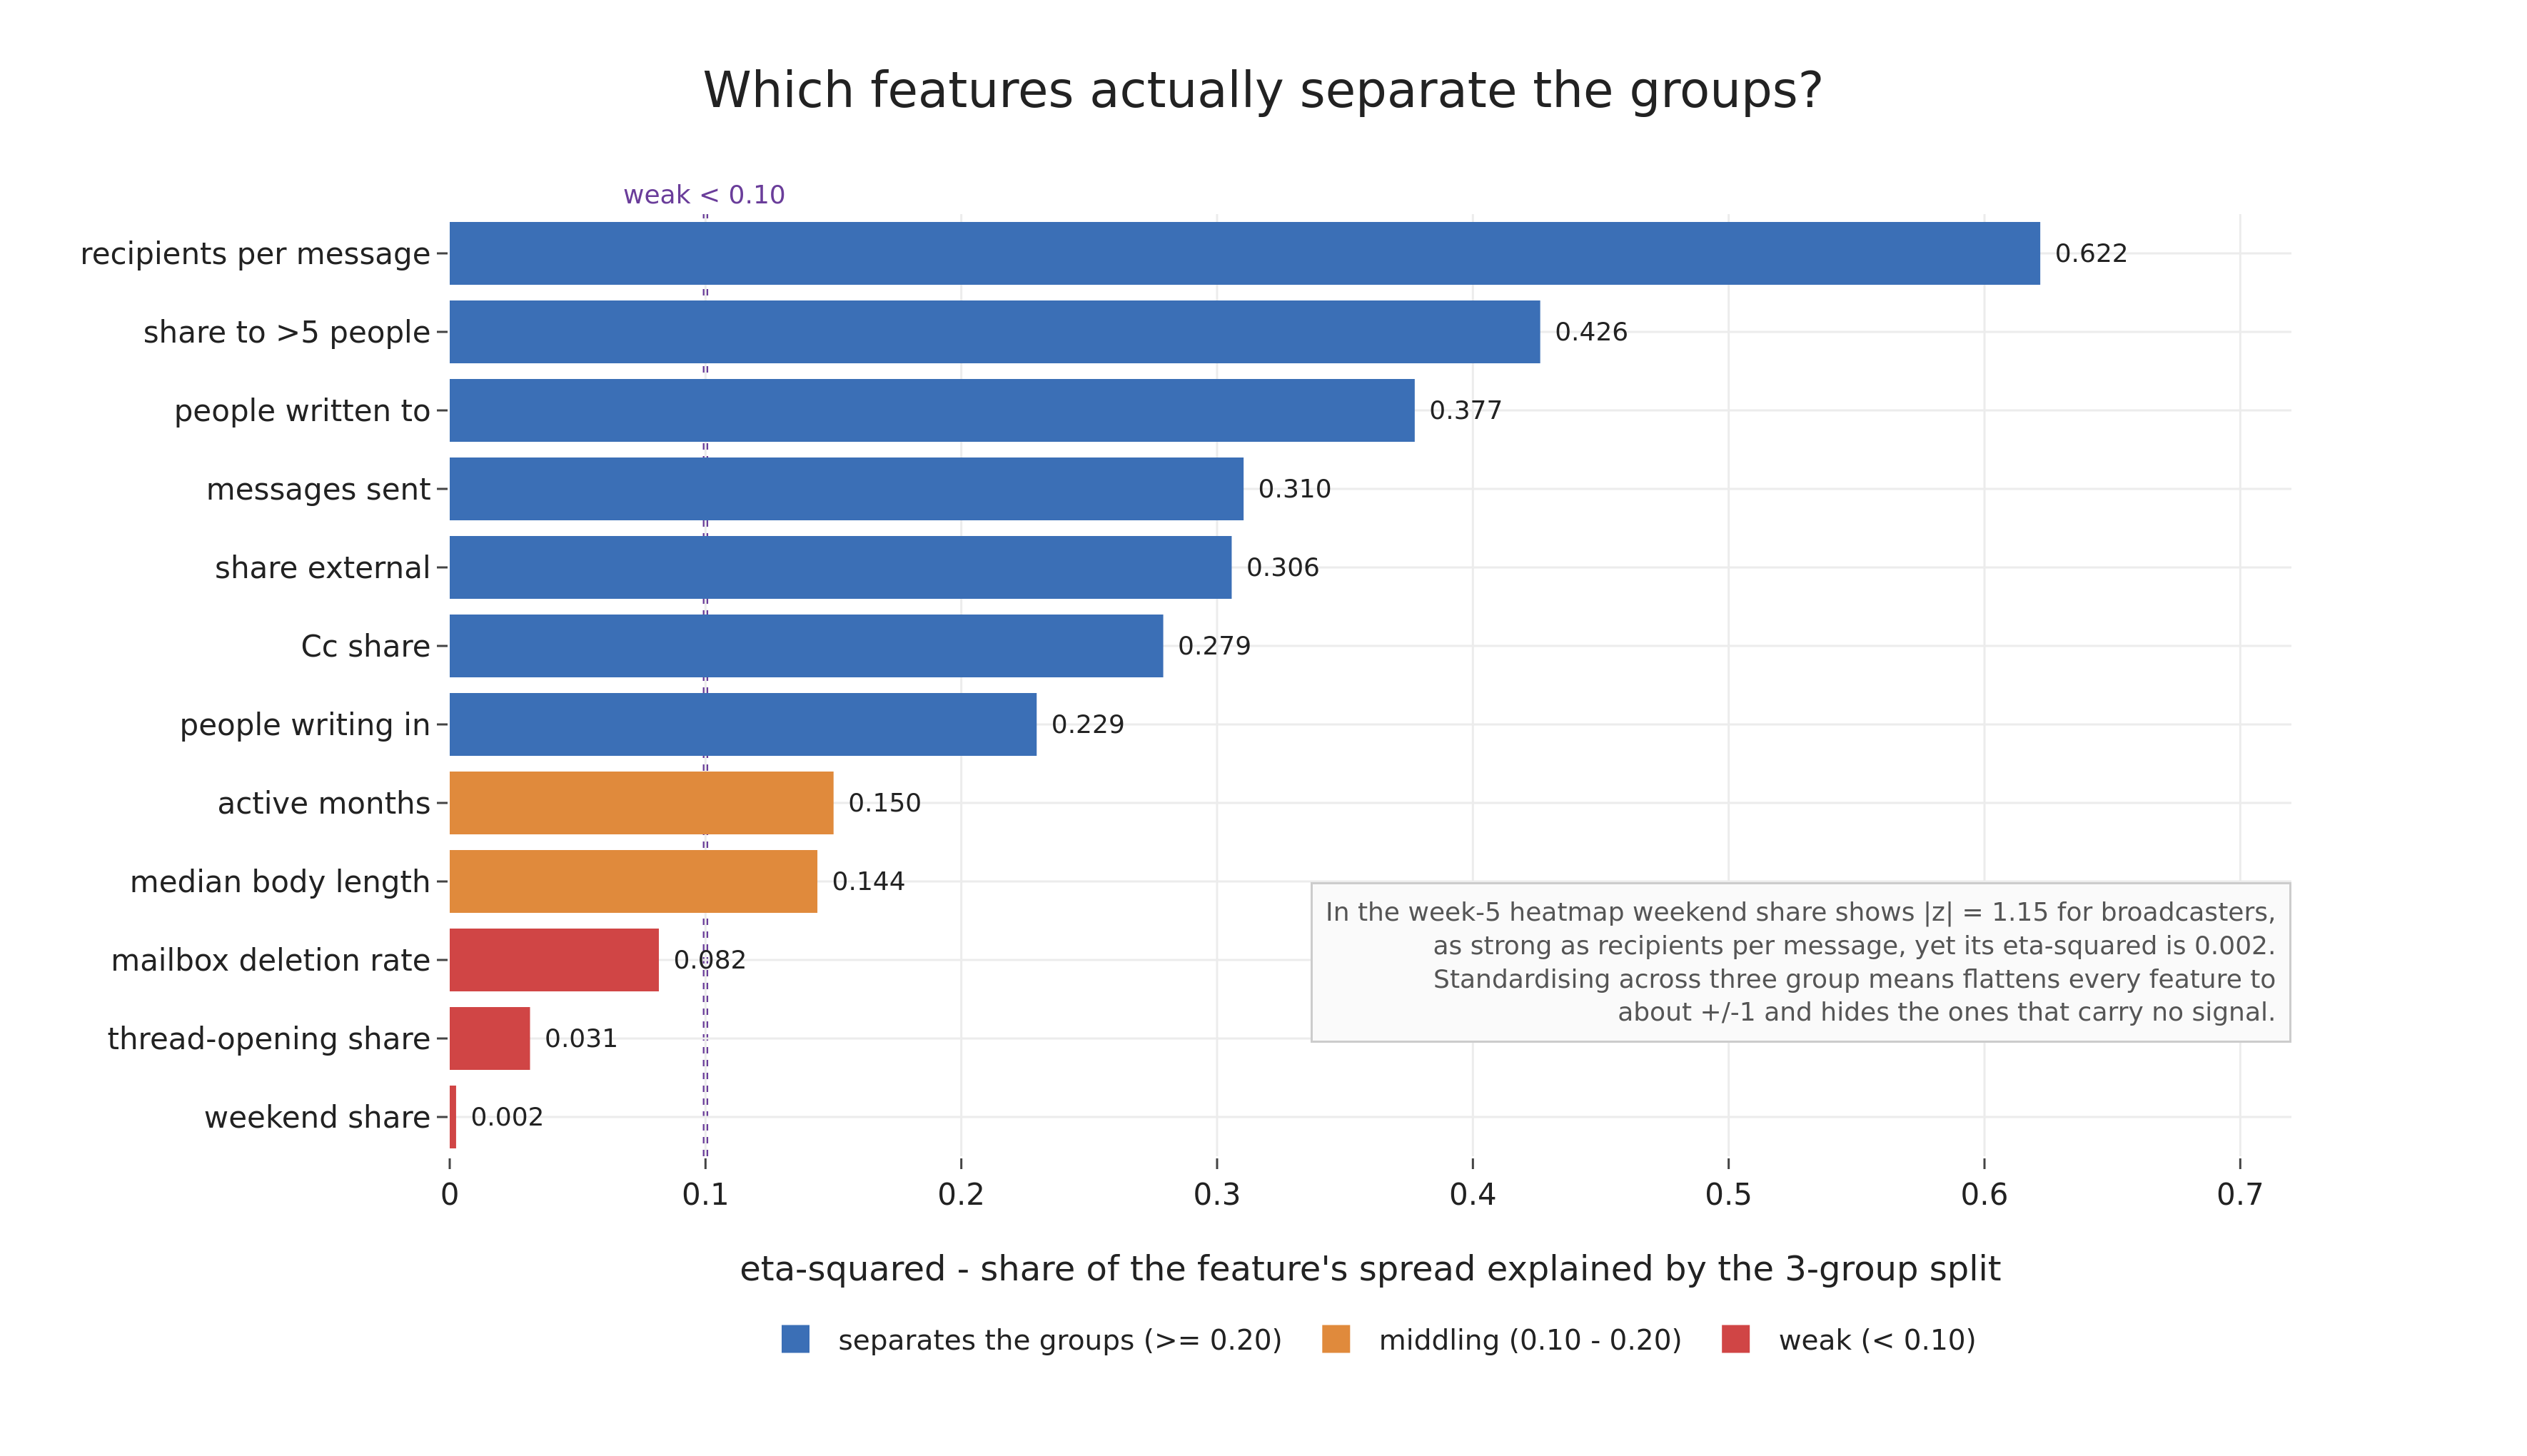

In [4]:
eta = {}
for j, f in enumerate(FEATS):
    x = X[:, j]; gm = x.mean(); sst = ((x - gm) ** 2).sum()
    ssb = sum((clabel == c).sum() * (x[clabel == c].mean() - gm) ** 2 for c in np.unique(clabel))
    eta[f] = ssb / sst
eta = pd.Series(eta).sort_values()

# crosscheck: how the heatmap's 3-group z compares to the population z and to eta-squared
prof_named = prof.rename(index=names)
z3   = (prof_named - prof_named.mean()) / prof_named.std()
zpop = (prof_named - Fraw[FEATS].mean()) / Fraw[FEATS].std()
chk = pd.DataFrame({"heatmap z (broadc.)": z3.loc["Broadcasters / execs"],
                    "population z (broadc.)": zpop.loc["Broadcasters / execs"],
                    "eta_squared": eta}).loc[["wknd_ratio", "root_ratio", "del_rate", "broadcast", "mean_recip"]]
chk.index = [PRETTY[i] for i in chk.index]
print(chk.round(3).to_string())

fn = [PRETTY[k] for k in eta.index]; ev = eta.values
barcol = [RED if v < 0.10 else (ORANGE if v < 0.20 else BLUE) for v in ev]
fig = go.Figure(go.Bar(y=fn, x=ev, orientation="h", marker_color=barcol,
    text=[f" {v:.3f}" for v in ev], textposition="outside", textfont=dict(size=12),
    cliponaxis=False, showlegend=False))
for col, nm in [(BLUE, "separates the groups (>= 0.20)"),
                (ORANGE, "middling (0.10 - 0.20)"), (RED, "weak (< 0.10)")]:
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
        marker=dict(size=13, color=col, symbol="square"), name=nm, showlegend=True))
fig.add_vline(x=0.10, line=dict(color=PURPLE, dash="dot", width=2.5), layer="below",
    annotation_text="weak &lt; 0.10", annotation_position="top",
    annotation_font=dict(size=12, color=PURPLE))
fig.update_xaxes(title_text="eta-squared - share of the feature's spread explained by the 3-group split",
    range=[0, 0.72])
fig.add_annotation(xref="paper", yref="paper", x=1.0, y=0.12, showarrow=False, xanchor="right", align="right",
    text="In the week-5 heatmap weekend share shows |z| = 1.15 for broadcasters,<br>"
         "as strong as recipients per message, yet its eta-squared is 0.002.<br>"
         "Standardising across three group means flattens every feature to<br>"
         "about +/-1 and hides the ones that carry no signal.",
    font=dict(size=12, color="#555"), bordercolor="#cccccc", borderwidth=1, borderpad=6, bgcolor="#fafafa")
fig.update_layout(title="Which features actually separate the groups?",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.16, yanchor="top", font=dict(size=13)))
save_fig(fig, "pc2_feature_separation.png", w=1180, h=680, margin=dict(l=210, r=110, t=100, b=140))

Two features carry most of the split. Recipients per message accounts for 62% of its own spread, and
the share of mail going to more than five people accounts for 43%, so the groups are really a story about
how widely people address their mail. Out-degree, raw volume and external share fill in behind them. At the
other end, three features do almost no separating work. Weekend share sits at 0.002, thread-opening at 0.03,
and the mailbox deletion rate at 0.08. Whatever group a person is in, these three look the same.

That is the answer to the worry about the heatmap, and the crosscheck table makes it concrete. Weekend share
reads as a strong broadcaster signature in the week-five heatmap, at minus 1.15 standard deviations, as
extreme as recipients per message. But measured against the whole population the broadcasters sit at minus
0.20 on weekend share, a small step, and the eta-squared confirms it explains essentially none of the split.
The broadcasters simply happen to fall on the low side of a feature on which everyone is scattered. The
heatmap's even colouring was the artefact, not the signal, so the groups rest on a handful of volume and
reach features rather than on the full set of twelve.

## What this says before the prediction work

Both checks point the same way. The broadcaster group has a real, stable core of eight, and we can name
them, but it is not the company's executives and its edge is fuzzy. The split itself runs on two or three
features about how widely people address mail, while a third of the features barely move between groups.
That matters for what comes next. A label this soft at the boundary, resting on so few features, is a
demanding target to predict from message text, and it is part of why the body-text models in
`enron_eda_week6.ipynb` recover the broadcasters so poorly once whole people are held out.